In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
nxl='/content/1. FallasTecnológicas.xlsx'
nxle= '/content/2. AdmonEjecProcesos.xlsx'

In [29]:
XDB = pd.read_excel(nxl, sheet_name=0)
XDBe = pd.read_excel(nxle, sheet_name=0)

print("Base interna")
display(XDB.head())

print("Base externa")
display(XDBe.head())


Base interna


,Fallas Tecnológicas (Canales Electronicos),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas (Freq),Valor Generado Promedio (Millones),Descripción Evento
1,2009-01-01 00:00:00,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
2,2009-01-02 00:00:00,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
3,2009-01-03 00:00:00,70,9.976,5,0.4269,"Errores visuales menores, problemas de usabili..."
4,2009-01-04 00:00:00,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."


Base externa


,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado (millones)
0,2010-01-01,44,358.3637,5,0.079029
1,2010-01-02,43,742.8517,7,0.021259
2,2010-01-03,55,646.6903,9,0.038818
3,2010-01-04,59,653.5397,3,0.035956
4,2010-01-05,52,636.6142,4,0.204951


In [30]:
Freq = pd.to_numeric(XDB.iloc[:,3], errors='coerce')
Sev = pd.to_numeric(XDB.iloc[:,4], errors='coerce')

LDA = Freq * Sev


Freqe = pd.to_numeric(XDBe.iloc[:,3], errors='coerce')
Seve = pd.to_numeric(XDBe.iloc[:,4], errors='coerce')

LDAe = Freqe * Seve


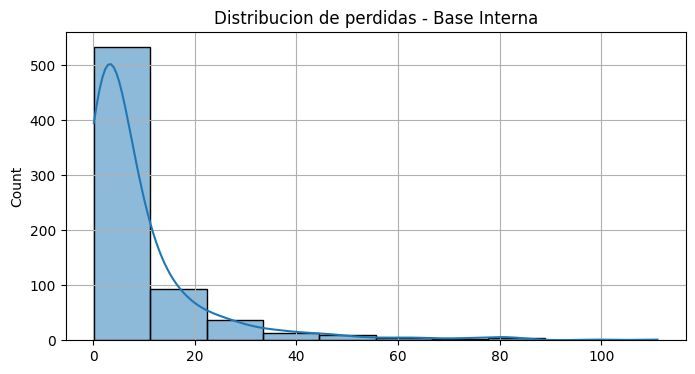

Media interna: 9.45111269614836
Desviacion interna: 13.707471533012761
Asimetria interna: 3.3483604527095365
Kurtosis interna: 14.16771362667782


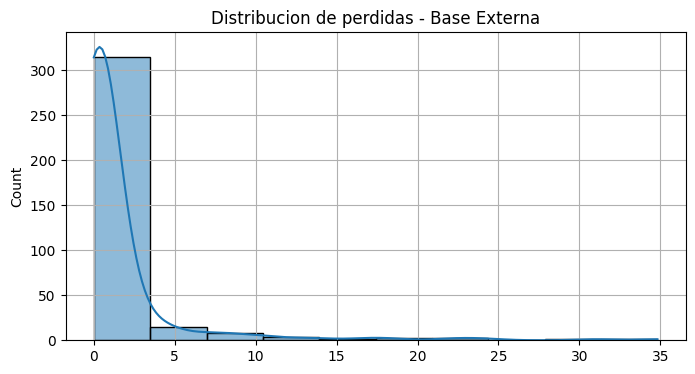


Media externa: 1.469187040102234
Desviacion externa: 4.008350447638778
Asimetria externa: 5.059212525816747
Kurtosis externa: 29.643693069779438


In [35]:

def caracterizacion(data,nombre_base):
    clean_data = data.dropna()

    plt.figure(figsize=(8, 4))
    sns.histplot(clean_data, bins=10, kde=True)
    plt.title(f"Distribucion de perdidas - {nombre_base}")
    plt.grid()
    plt.show()

    media = np.mean(clean_data)
    sigma = np.std(clean_data)
    asimetria = stats.skew(clean_data)
    kurt = stats.kurtosis(clean_data)

    return media, sigma, asimetria, kurt

uo, sigmao, Caso, Kuro = caracterizacion(LDA, "Base Interna")

print("Media interna:", uo)
print("Desviacion interna:", sigmao)
print("Asimetria interna:", Caso)
print("Kurtosis interna:", Kuro)

ue, sigmae, Case, Kue = caracterizacion(LDAe, "Base Externa")

print("\nMedia externa:", ue)
print("Desviacion externa:", sigmae)
print("Asimetria externa:", Case)
print("Kurtosis externa:", Kue)


In [32]:
#NDo = len(LDA)
NDe = len(LDAe)

# media hipotetica
uhat = (uo*NDo + ue*NDe) / (NDo + NDe)

# EPV
EPV = (sigmao**2*NDo + sigmae**2*NDe) / (NDo + NDe)

# VHM
VHM = ((NDo*uo**2 + NDe*ue**2) / (NDo + NDe)) - uhat**2

# factor credibilidad
fc = EPV / VHM

# credibilidad
Cr = (NDo / (NDo + fc))

print("Credibilidad:", Cr)


Credibilidad: 0.986998621069865


In [33]:
PEs = Cr * uo + (1 - Cr) * ue

print("Perdidas asumibles:", PEs)

Perdidas asumibles: 9.34733665610194


Se realizó la caracterización de la distribución agregada de pérdidas para la base interna y la base externa utilizando medidas de tendencia central y dispersión. La base interna presentó una media de 9.45 millones y una desviación estándar de 13.71 millones, lo que indica un alto nivel promedio de pérdidas y una elevada variabilidad. Asimismo, presentó una asimetría positiva de 3.35 y una kurtosis de 14.17, evidenciando la presencia de eventos extremos y una distribución con colas pesadas.

Por su parte, la base externa presentó una media de 1.47 millones y una desviación estándar de 4.01 millones, valores significativamente menores que los observados en la base interna. Además, mostró una asimetría de 5.06 y una kurtosis de 29.64, indicando una distribución altamente asimétrica y con presencia de eventos extremos severos.

Posteriormente, mediante la Teoría de la Credibilidad, se obtuvo un factor de credibilidad de 98.7%, lo que indica que la base interna es altamente representativa del comportamiento del riesgo operacional. Esto significa que la base externa aporta únicamente un 1.3% de información adicional en la estimación del riesgo.

Finalmente, la integración de ambas bases de datos permitió estimar unas pérdidas asumibles de 9.35 millones, valor muy cercano a la media de la base interna, lo que confirma que la estimación integrada está dominada principalmente por la experiencia interna de la organización.